請選擇1~5年：1
----------------------------------------
【大盤組策略結算報告】
回測年數: 1 年 (2025 ~ 2025)
初始資金: 1,000,000 TWD
最終淨值: 1,376,840 TWD (已扣除最終賣出成本)
淨所得: 376,840 TWD
累積淨報酬率: 37.68%
夏普值: 1.40
----------------------------------------


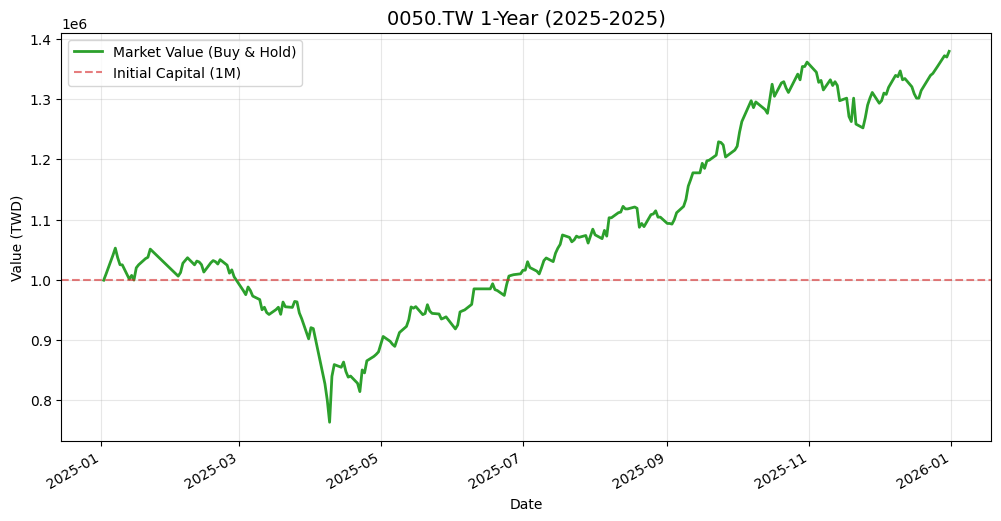

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#設定參數
ticker_symbol = "0050.TW"
initial_capital = 1000000
fee_rate = 0.001425
fee_discount = 0.6
tax_rate = 0.001

#輸入年分
while True:
    try:
        years = int(input("請選擇1~5年："))
        if years in [1, 2, 3, 4, 5]:
            break
        else:
            print("請輸入1, 2, 3, 4, 5")
    except ValueError:
        print("請輸入數字！")
start_year = 2026 - years
start_date = f"{start_year}-01-01"
end_date = "2026-01-01"

#下載資料
stock = yf.Ticker(ticker_symbol)
df = stock.history(start=start_date, end=end_date)
if df.empty:
    print("找不到資料")
else:
    prices = df['Close']
    start_price = prices.iloc[0]
    buy_fee_factor = 1 + (fee_rate * fee_discount)
    shares_owned = initial_capital / (start_price * buy_fee_factor)

    # 計算每日的市場價值 (帳面價值)
    market_value_series = prices * shares_owned

    #計算夏普值
    daily_returns = market_value_series.pct_change().dropna()
    risk_free_rate = 0.02  # 假設年化無風險利率 2%
    trading_days_per_year = 252
    annual_return = daily_returns.mean() * trading_days_per_year
    annual_volatility = daily_returns.std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

    #結算
    final_market_value = market_value_series.iloc[-1]
    exit_costs = final_market_value * (fee_rate * fee_discount + tax_rate)
    final_net_value = final_market_value - exit_costs
    total_net_profit = final_net_value - initial_capital
    net_roi = (total_net_profit / initial_capital) * 100

    #資料視覺化
    plt.figure(figsize=(12, 6))
    plt.plot(market_value_series.index, market_value_series.values, color='#2ca02c', linewidth=2, label='Market Value (Buy & Hold)')
    plt.axhline(y=initial_capital, color='#d62728', linestyle='--', alpha=0.6, label='Initial Capital (1M)')
    plt.title(f'{ticker_symbol} {years}-Year ({start_year}-2025)', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Value (TWD)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.gcf().autofmt_xdate()

    #輸出結算報告
    print("-" * 40)
    print(f"【大盤組策略結算報告】")
    print(f"回測年數: {years} 年 ({start_year} ~ 2025)")
    print(f"初始資金: {initial_capital:,.0f} TWD")
    print(f"最終淨值: {final_net_value:,.0f} TWD (已扣除最終賣出成本)")
    print(f"淨所得: {total_net_profit:,.0f} TWD")
    print(f"累積淨報酬率: {net_roi:.2f}%")
    print(f"夏普值: {sharpe_ratio:.2f}")
    print("-" * 40)

    plt.show()